# Tratamento de Dados - DATASUS (Dengue)
Processamento, limpeza e padronização dos dados de notificação de dengue do SINAN.

**Etapas:**
1. Carregamento dos CSVs brutos (2025 e 2026)
2. Exploração inicial (tipos, nulos, estatísticas)
3. Tratamento de colunas de data
4. Padronização de tipos numéricos
5. Codificação de variáveis categóricas
6. Decodificação da idade (codificação SINAN)
7. Tratamento de valores nulos
8. Exportação dos dados tratados


In [1]:
import pandas as pd
import numpy as np
import os, warnings
from scipy import stats
import seaborn as sns
sns.set_style('dark')
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', None)


In [2]:
base = os.getcwd()
base = os.path.dirname(base)
base

'c:\\Users\\vitor\\OneDrive\\Documentos\\Github\\estudo_dengue'

In [3]:
# ============================================================
# 2. CARREGAMENTO DOS DADOS
# ============================================================
# Detectar diretório base: se estiver em etl/, sobe um nível
BASE = os.getcwd()
if BASE.endswith('etl'):
    BASE = os.path.dirname(BASE)
PASTA_DADOS = os.path.join(BASE, 'dados')

df_25 = pd.read_csv(os.path.join(PASTA_DADOS, 'DENGBR25.csv'), low_memory=False)
df_26 = pd.read_csv(os.path.join(PASTA_DADOS, 'DENGBR26.csv'), low_memory=False)

print(f'DENGBR25: {df_25.shape[0]} linhas, {df_25.shape[1]} colunas')
print(f'DENGBR26: {df_26.shape[0]} linhas, {df_26.shape[1]} colunas')

# Concatenar
df = pd.concat([df_25, df_26], ignore_index=True)
print(f'\nDataset final: {df.shape[0]} linhas, {df.shape[1]} colunas')
print(f'Anos: {sorted(df["NU_ANO"].unique())}')
print(f'Municípios notificantes: {df["ID_MUNICIP"].nunique()}')


DENGBR25: 1646621 linhas, 121 colunas
DENGBR26: 309957 linhas, 121 colunas

Dataset final: 1956578 linhas, 121 colunas
Anos: [np.int64(2024), np.int64(2025), np.int64(2026)]
Municípios notificantes: 5031


## 3. Exploração inicial

In [4]:
print('=== TIPOS ===')
print(df.dtypes.value_counts())

print('\n=== AMOSTRA ===')
df.head(3)


=== TIPOS ===
float64    93
str        16
int64      10
object      2
Name: count, dtype: int64

=== AMOSTRA ===


,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W
0,2,A90,2024-12-29,202501,2024,32,320070,32004,2485397.0,2024-12-29,202501,2003.0,4021,M,6.0,4.0,6.0,32,320070.0,32004.0,1,2024-12-29,10001,1.0,1.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,4.0,NaN,4.0,NaN,4.0,NaN,4.0,0.0,0.0,0.0,2.0,NaN,0.0,0.0,1.0,0.0,0,0.0,10.0,2.0,0.0,0.0,0.0,NaN,2025-10-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-12-29,0.0,0.0,0.0
1,2,A90,2024-12-29,202501,2024,32,320020,32004,2448025.0,2024-12-29,202501,1952.0,4072,F,5.0,1.0,1.0,32,320020.0,32004.0,1,2024-12-29,999990,1.0,1.0,1.0,2.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,1.0,2.0,2.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,4.0,NaN,4.0,NaN,4.0,NaN,4.0,0.0,0.0,0.0,2.0,NaN,0.0,0.0,1.0,0.0,0,0.0,10.0,2.0,0.0,0.0,1.0,NaN,2025-11-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-12-29,0.0,0.0,0.0
2,2,A90,2024-12-29,202501,2024,32,320020,32004,2448025.0,2024-12-29,202501,1951.0,4073,M,6.0,4.0,1.0,32,320020.0,32004.0,1,2024-12-29,999990,1.0,2.0,1.0,2.0,1.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,NaN,NaN,NaN,0.0,0.0,0.0,NaN,4.0,NaN,4.0,NaN,4.0,NaN,4.0,0.0,0.0,0.0,2.0,NaN,0.0,0.0,1.0,0.0,0,0.0,10.0,2.0,0.0,0.0,1.0,NaN,2025-11-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2024-12-29,0.0,0.0,0.0


In [5]:
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(2)
null_df = pd.DataFrame({'nulos': nulls, '%': nulls_pct})
null_df = null_df[null_df['nulos'] > 0].sort_values('nulos', ascending=False)
print(f'Colunas com nulos: {len(null_df)}')
null_df.head(30)


Colunas com nulos: 107


,nulos,%
DT_CHIK_S2,1956578,100.00
DT_PRNT,1956578,100.00
DT_CHIK_S1,1956577,100.00
DT_OBITO,1953808,99.86
DT_GRAV,1952840,99.81
DT_NS1,1949478,99.64
DT_VIRAL,1947160,99.52
DT_ALRM,1917002,97.98
RESUL_PRNT,1910592,97.65
RESUL_NS1,1910592,97.65


## 4. Conversão de Datas

In [6]:
# ============================================================
# 4. CONVERSÃO DE COLUNAS DE DATA
# ============================================================
DATE_COLS = [
    'DT_NOTIFIC', 'DT_SIN_PRI', 'DT_INVEST', 'DT_SORO', 'DT_NS1',
    'DT_PCR', 'DT_INTERNA', 'DT_ENCERRA', 'DT_ALRM', 'DT_GRAV',
    'DT_DIGITA', 'DT_OBITO'
]
for col in DATE_COLS:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# DT_VIRAL
if 'DT_VIRAL' in df.columns:
    df['DT_VIRAL'] = pd.to_datetime(df['DT_VIRAL'], errors='coerce')

# Colunas de chikungunya (quase sempre vazias)
for col in ['DT_CHIK_S1', 'DT_CHIK_S2', 'DT_PRNT']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

print('Datas convertidas.')
date_cols = [c for c in df.columns if 'DT_' in c and pd.api.types.is_datetime64_any_dtype(df[c])] ####################################################################33
print(f'{len(date_cols)} colunas datetime')


Datas convertidas.
16 colunas datetime


In [7]:
# Verificar range
for col in date_cols:
    valid = df[col].dropna()
    if len(valid) > 0:
        print(f'{col:20s}  {valid.min().date()}  ->  {valid.max().date()}  ({len(valid):>8,} válidas)')
    else:
        print(f'{col:20s}  [todas vazias]')


DT_NOTIFIC            2024-12-29  ->  2026-12-01  (1,956,578 válidas)
DT_SIN_PRI            2024-12-29  ->  2026-05-09  (1,956,578 válidas)
DT_INVEST             2014-03-27  ->  2026-12-01  (1,887,653 válidas)
DT_CHIK_S1            2025-04-16  ->  2025-04-16  (       1 válidas)
DT_CHIK_S2            [todas vazias]
DT_PRNT               [todas vazias]
DT_SORO               2024-04-11  ->  2026-10-01  ( 312,633 válidas)
DT_NS1                1920-01-05  ->  2026-08-01  (   7,100 válidas)
DT_VIRAL              2024-12-31  ->  2026-10-02  (   9,418 válidas)
DT_PCR                2023-02-22  ->  2026-06-01  (  90,034 válidas)
DT_INTERNA            1942-08-01  ->  2026-10-01  (  80,563 válidas)
DT_OBITO              2025-01-01  ->  2026-08-01  (   2,770 válidas)
DT_ENCERRA            2024-02-06  ->  2026-12-02  (1,825,423 válidas)
DT_ALRM               1960-11-17  ->  2202-03-28  (  39,576 válidas)
DT_GRAV               2024-01-03  ->  2202-02-16  (   3,738 válidas)
DT_DIGITA             202

## 5. Padronização de Tipos Numéricos

In [8]:
# ============================================================
# 5.1 Colunas binárias (1=Sim, 2=Não) - converter com tolerância
# ============================================================
def safe_to_int64(ser):
    return pd.to_numeric(ser, errors="coerce").astype("Int64")

BINARY_COLS = [
    'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA',
    'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA', 'PETEQUIA_N',
    'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES', 'HEMATOLOG',
    'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE',
    'HOSPITALIZ', 'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG',
    'ALRM_HEMAT', 'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ',
    'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI',
    'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO',
    'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO',
    'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS',
    'HEMATURA', 'SANGRAM', 'LACO_N', 'PLASMATICO', 'EVIDENCIA',
    'PLAQ_MENOR', 'CON_FHD', 'TPAUTOCTO', 'CLINC_CHIK'
]
for col in BINARY_COLS:
    if col in df.columns:
        df[col] = safe_to_int64(df[col])

print(f'{len(BINARY_COLS)} colunas binárias convertidas')


60 colunas binárias convertidas


In [9]:
# ============================================================
# 5.2 Resultados de exames e outras colunas numéricas
# ============================================================
NUM_COLS = [
    'RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_',
    'RES_CHIKS1', 'RES_CHIKS2', 'RESUL_PRNT', 'SOROTIPO',
    'HISTOPA_N', 'IMUNOH_N', 'COMPLICA', 'DOENCA_TRA',
    'TP_NOT', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W',
    'NDUPLIC_N', 'TP_SISTEMA'
]
for col in NUM_COLS:
    if col in df.columns:
        df[col] = safe_to_int64(df[col])

print(f'{len(NUM_COLS)} colunas numéricas convertidas')


18 colunas numéricas convertidas


In [10]:
# ============================================================
# 5.3 IDs e códigos (tolerantes a não numéricos)
# ============================================================
ID_COLS = [
    'ID_MUNICIP', 'ID_REGIONA', 'ID_UNIDADE', 'ID_MN_RESI',
    'ID_RG_RESI', 'ID_PAIS', 'ID_OCUPA_N', 'MUNICIPIO',
    'COUFINF', 'COPAISINF', 'COMUNINF'
]
for col in ID_COLS:
    if col in df.columns:
        df[col] = safe_to_int64(df[col])

print(f'{len(ID_COLS)} colunas de ID convertidas')


11 colunas de ID convertidas


In [11]:

NUMERIC_COLS = ID_COLS + BINARY_COLS + NUM_COLS

In [12]:
print(NUMERIC_COLS)

['ID_MUNICIP', 'ID_REGIONA', 'ID_UNIDADE', 'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'ID_OCUPA_N', 'MUNICIPIO', 'COUFINF', 'COPAISINF', 'COMUNINF', 'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA', 'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA', 'PETEQUIA_N', 'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES', 'HEMATOLOG', 'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE', 'HOSPITALIZ', 'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT', 'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ', 'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO', 'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS', 'HEMATURA', 'SANGRAM', 'LACO_N', 'PLASMATICO', 'EVIDENCIA', 'PLAQ_MENOR', 'CON_FHD', 'TPAUTOCTO', 'CLINC_CHIK', 'RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_', 'RES_CHIKS1', 'RES_CHIKS2', 'RESUL_PR

In [13]:
# ============================================================
# 5.4 UF - tratar como string (pode ter siglas ou números)
# ============================================================
UF_MAP = {
    'ac': '12', 'al': '27', 'ap': '16', 'am': '13', 'ba': '29', 'ce': '23',
    'df': '53', 'es': '32', 'go': '52', 'ma': '21', 'mt': '51', 'ms': '50',
    'mg': '31', 'pa': '15', 'pb': '25', 'pr': '41', 'pe': '26', 'pi': '22',
    'rj': '33', 'rn': '24', 'rs': '43', 'ro': '11', 'rr': '14', 'sc': '42',
    'sp': '35', 'se': '28', 'to': '17'
}

def padronizar_uf(ser):
    s = ser.astype(str).str.lower().str.strip()
    s = s.map(lambda x: UF_MAP.get(x, x)) ############################################################################
    s = s.replace(['nan', 'none', ''], None)
    s = s.str.zfill(2) ###################################3
    return s.astype('category')

for col in ['SG_UF_NOT', 'SG_UF', 'UF']:
    if col in df.columns:
        df[col] = padronizar_uf(df[col])

print('UFs padronizadas:', df['SG_UF_NOT'].cat.categories.tolist())


UFs padronizadas: ['11', '12', '13', '14', '15', '16', '17', '21', '22', '23', '24', '25', '26', '27', '28', '29', '31', '32', '33', '35', '41', '42', '43', '50', '51', '52', '53']


## 6. Variáveis Categóricas

In [14]:
# ============================================================
# 6.1 Sexo
# ============================================================
df['CS_SEXO'] = df['CS_SEXO'].astype(str).str.upper().str.strip()
df['CS_SEXO'] = df['CS_SEXO'].replace(['I', 'NAN', 'NONE', ''], None)
df['CS_SEXO'] = df['CS_SEXO'].astype('category')#######################################################
print('CS_SEXO:', df['CS_SEXO'].value_counts(dropna=False).to_dict())


CS_SEXO: {'F': 1062221, 'M': 892983, nan: 1374}


In [15]:
# ============================================================
# 6.2 Gestante
# ============================================================
# 1=1ºtrim, 2=2ºtrim, 3=3ºtrim, 4=id_gest_ign, 5=não, 6=não se aplica, 9=ign
GESTANT_MAP = {
    1: '1o_trimestre', 2: '2o_trimestre', 3: '3o_trimestre',
    4: 'id_gest_ignorada', 5: 'nao', 6: 'nao_se_aplica', 9: 'ignorado'
}
df['CS_GESTANT'] = safe_to_int64(df['CS_GESTANT']).map(GESTANT_MAP).astype('category')
print('CS_GESTANT:', df['CS_GESTANT'].value_counts(dropna=False).to_dict())


CS_GESTANT: {'nao_se_aplica': 1071843, 'nao': 739990, 'ignorado': 128158, '2o_trimestre': 5242, '1o_trimestre': 4439, '3o_trimestre': 4195, 'id_gest_ignorada': 2482, nan: 229}


In [16]:
# ============================================================
# 6.3 Raça
# ============================================================
RACA_MAP = {1: 'Branca', 2: 'Preta', 3: 'Amarela', 4: 'Parda', 5: 'Indígena'}
df['CS_RACA'] = safe_to_int64(df['CS_RACA']).map(RACA_MAP).astype('category')
print('CS_RACA:', df['CS_RACA'].value_counts(dropna=False).to_dict())


CS_RACA: {'Branca': 896683, 'Parda': 690596, nan: 244464, 'Preta': 95179, 'Amarela': 25170, 'Indígena': 4486}


In [17]:
# ============================================================
# 6.4 Escolaridade
# ============================================================
ESCOL_MAP = {
    0: 'sem_escolaridade', 1: 'fund_incompleto_1a4', 2: 'fund_completo_5a8',
    3: 'fund_completo', 4: 'medio_incompleto', 5: 'medio_completo',
    6: 'superior_incompleto', 7: 'superior_completo', 8: 'nao_se_aplica',
    9: 'ignorado', 10: 'fund_1a4'
}
df['CS_ESCOL_N'] = safe_to_int64(df['CS_ESCOL_N']).map(ESCOL_MAP).astype('category')
print('CS_ESCOL_N:', df['CS_ESCOL_N'].value_counts(dropna=False).to_dict())


CS_ESCOL_N: {'ignorado': 596863, 'superior_incompleto': 368708, nan: 348368, 'fund_1a4': 134460, 'nao_se_aplica': 103851, 'medio_completo': 102106, 'fund_completo': 100130, 'medio_incompleto': 70500, 'fund_incompleto_1a4': 58629, 'fund_completo_5a8': 36033, 'superior_completo': 29655, 'sem_escolaridade': 7275}


In [18]:
# ============================================================
# 6.5 Classificação final
# ============================================================
CLASSI_MAP = {
    0: 'descartado', 1: 'dengue_classico', 2: 'dengue_hemorragico',
    3: 'sindrome_choque', 4: 'sindrome_especial', 5: 'obito_dengue',
    8: 'inconclusivo', 10: 'dengue', 11: 'chikungunya',
    12: 'doenca_aguda_nao_especificada', 13: 'zika'
}
df['CLASSI_FIN'] = safe_to_int64(df['CLASSI_FIN']).map(CLASSI_MAP).astype('category')
print('CLASSI_FIN:', df['CLASSI_FIN'].value_counts(dropna=False).to_dict())


CLASSI_FIN: {'dengue': 1614348, 'inconclusivo': 189264, nan: 103353, 'chikungunya': 40783, 'descartado': 5731, 'doenca_aguda_nao_especificada': 3099}


In [19]:
# ============================================================
# 6.6 Critério de confirmação
# ============================================================
CRITERIO_MAP = {
    0: 'descartado', 1: 'laboratorial', 2: 'clinico_epidemiologico',
    3: 'vinculo_epidemiologico', 4: 'exame_inespecifico'
}
df['CRITERIO'] = safe_to_int64(df['CRITERIO']).map(CRITERIO_MAP).astype('category')
print('CRITERIO:', df['CRITERIO'].value_counts(dropna=False).to_dict())


CRITERIO: {'clinico_epidemiologico': 1067872, 'laboratorial': 573031, nan: 262651, 'vinculo_epidemiologico': 47505, 'descartado': 5519}


In [20]:
# ============================================================
# 6.7 Evolução
# ============================================================
EVOLUCAO_MAP = {0: 'ignorado', 1: 'cura', 2: 'obito_dengue', 3: 'obito_outra_causa'}
df['EVOLUCAO'] = safe_to_int64(df['EVOLUCAO']).map(EVOLUCAO_MAP).astype('category')
print('EVOLUCAO:', df['EVOLUCAO'].value_counts(dropna=False).to_dict())


EVOLUCAO: {'cura': 1545402, nan: 401599, 'ignorado': 7081, 'obito_dengue': 1955, 'obito_outra_causa': 541}


In [21]:
# ============================================================
# 6.8 ID_AGRAVO
# ============================================================
df['ID_AGRAVO'] = df['ID_AGRAVO'].astype('category')
print('ID_AGRAVO:', df['ID_AGRAVO'].value_counts(dropna=False).to_dict())


ID_AGRAVO: {'A90': 1956578}


## 7. Idade (decodificação SINAN)

In [22]:
# ============================================================
# 7. DECODIFICAÇÃO DA IDADE
# ============================================================
# NU_IDADE_N: 4xxx=anos, 3xxx=meses, 2xxx=dias, 1xxx=horas
df['NU_IDADE_N'] = safe_to_int64(df['NU_IDADE_N'])
df['ANO_NASC'] = safe_to_int64(df['ANO_NASC'])

def decode_idade(val):
    if pd.isna(val):
        return ('ignorado', 0)
    v = int(val)
    if v >= 4000:  return ('anos', v - 4000)
    elif v >= 3000: return ('meses', v - 3000)
    elif v >= 2000: return ('dias', v - 2000)
    elif v >= 1000: return ('horas', v - 1000)
    return ('ignorado', 0)

df['IDADE_TIPO'] = df['NU_IDADE_N'].apply(lambda x: decode_idade(x)[0])
df['IDADE_VALOR'] = df['NU_IDADE_N'].apply(lambda x: decode_idade(x)[1])
df['IDADE_ANOS'] = np.where(
    df['IDADE_TIPO'] == 'anos', df['IDADE_VALOR'],
    np.where(df['IDADE_TIPO'] == 'meses', (df['IDADE_VALOR'] / 12).round(1),
             np.where(df['IDADE_TIPO'] == 'dias', (df['IDADE_VALOR'] / 365).round(3), None)) ##############################################################
)

print(f'Idade: {df["IDADE_VALOR"].min()} a {df["IDADE_VALOR"].max()} ({df["IDADE_TIPO"].mode()[0]})')
print('Tipos:', df['IDADE_TIPO'].value_counts().to_dict())


Idade: 0 a 407 (anos)
Tipos: {'anos': 1938420, 'meses': 13270, 'dias': 4847, 'horas': 31, 'ignorado': 10}


## 8. Tratamento de Valores Nulos

In [23]:
# ============================================================
# 8. ESTRATÉGIA DE NULOS
# ============================================================
# Sintomas/comorbidades sem preenchimento -> assumir "Não" (2)
# Exames sem resultado -> manter NaN (não realizado)
# Datas sem informação -> manter NaT

nulos_antes = df.isnull().sum().sum()
print(f'Total de nulos antes: {nulos_antes:,}')


Total de nulos antes: 125,786,633


In [24]:
# Preencher sintomas, comorbidades, alarme, gravidade, hemorragia
FILL_COLS = (
    ['FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA',
     'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA', 'PETEQUIA_N',
     'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES', 'HEMATOLOG',
     'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE']
    + [c for c in df.columns if c.startswith('ALRM_')]
    + [c for c in df.columns if c.startswith('GRAV_')]
    + ['MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS',
       'HEMATURA', 'SANGRAM', 'LACO_N', 'PLASMATICO', 'EVIDENCIA',
       'PLAQ_MENOR', 'CON_FHD', 'CLINC_CHIK', 'HOSPITALIZ',
       'TPAUTOCTO']
)
for col in FILL_COLS:
    if col in df.columns and df[col].isna().any():##########################################################
        n = df[col].isna().sum()
        df[col] = df[col].fillna(2)
        print(f'{col:20s}: {n:>8,} nulos -> 2 (Não)')


FEBRE               :   68,974 nulos -> 2 (Não)
MIALGIA             :   68,974 nulos -> 2 (Não)
CEFALEIA            :   68,974 nulos -> 2 (Não)
EXANTEMA            :   68,974 nulos -> 2 (Não)
VOMITO              :   68,974 nulos -> 2 (Não)
NAUSEA              :   68,974 nulos -> 2 (Não)
DOR_COSTAS          :   68,974 nulos -> 2 (Não)
CONJUNTVIT          :   68,974 nulos -> 2 (Não)
ARTRITE             :   68,974 nulos -> 2 (Não)
ARTRALGIA           :   68,974 nulos -> 2 (Não)
PETEQUIA_N          :   68,974 nulos -> 2 (Não)
LEUCOPENIA          :   68,974 nulos -> 2 (Não)
LACO                :   68,974 nulos -> 2 (Não)
DOR_RETRO           :   68,974 nulos -> 2 (Não)
DIABETES            :   68,974 nulos -> 2 (Não)
HEMATOLOG           :   68,974 nulos -> 2 (Não)
HEPATOPAT           :   68,974 nulos -> 2 (Não)
RENAL               :   68,974 nulos -> 2 (Não)
HIPERTENSA          :   68,974 nulos -> 2 (Não)
ACIDO_PEPT          :   68,974 nulos -> 2 (Não)
AUTO_IMUNE          :   68,974 nulos -> 

In [25]:
# Exames: manter NaN (não realizado)
EXAME_COLS = [
    'RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_',
    'HISTOPA_N', 'IMUNOH_N', 'SOROTIPO',
    'RES_CHIKS1', 'RES_CHIKS2', 'RESUL_PRNT'
]
for col in EXAME_COLS:
    if col in df.columns:
        n = df[col].isna().sum()
        if n > 0:
            print(f'{col:20s}: {n:>8,} nulos (mantidos)')


RESUL_SORO          : 1,910,592 nulos (mantidos)
RESUL_NS1           : 1,910,592 nulos (mantidos)
RESUL_VI_N          : 1,039,140 nulos (mantidos)
RESUL_PCR_          :  990,633 nulos (mantidos)
HISTOPA_N           : 1,117,277 nulos (mantidos)
IMUNOH_N            : 1,117,089 nulos (mantidos)
SOROTIPO            : 1,850,538 nulos (mantidos)
RES_CHIKS1          :  842,582 nulos (mantidos)
RES_CHIKS2          : 1,910,592 nulos (mantidos)
RESUL_PRNT          : 1,910,592 nulos (mantidos)


## 9. Verificação Final

In [26]:
print('=== RESUMO FINAL ===')
print(f'Linhas:  {df.shape[0]:>12,}')
print(f'Colunas: {df.shape[1]:>12,}')
print(f'Nulos:   {df.isnull().sum().sum():>12,}  '
      f'({(df.isnull().sum().sum() / df.size * 100):.2f}%)')

print('\n=== TIPOS ===')
print(df.dtypes.value_counts())

print('\n=== NULOS RESTANTES ===')
nulls_final = df.isnull().sum()
nulls_final = nulls_final[nulls_final > 0].sort_values(ascending=False)
if len(nulls_final) > 0:
    for col, v in nulls_final.items():
        print(f"{col:20s}: {v:>10,}  ({v/len(df)*100:5.1f}%)")
else:
    print('Nenhum nulo restante!')


=== RESUMO FINAL ===
Linhas:     1,956,578
Colunas:          124
Nulos:     53,077,428  (21.88%)

=== TIPOS ===
Int64             91
datetime64[us]    14
int64              4
category           2
datetime64[s]      2
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
str                1
object             1
Name: count, dtype: int64

=== NULOS RESTANTES ===
DT_PRNT             :  1,956,578  (100.0%)
DT_CHIK_S2          :  1,956,578  (100.0%)
DT_CHIK_S1          :  1,956,577  (100.0%)
DT_OBITO            :  1,953,808  ( 99.9%)
DT_GRAV             :  1,952,840  ( 99.8%)
DT_NS1              :  1,949,478  ( 99.6%)
DT_VIRAL            :  1,947,160  ( 99.5%)
DT_ALRM             :  1,917,002  ( 98.0%)
RESUL_SORO          :  1,910,592  ( 97.6%)
RESUL_NS1           :  1,910,592  ( 97.6%)
DOENCA_TRA          :  1,910,592  ( 97.6%)
RES_CHIKS2          :  1,910

In [27]:
print('=== DISTRIBUIÇÕES ===')
for col in ['CS_SEXO', 'CS_RACA', 'CLASSI_FIN', 'CRITERIO', 'EVOLUCAO', 'HOSPITALIZ']:
    print(f'\n{col}:')
    print(df[col].value_counts(dropna=False).to_string())


=== DISTRIBUIÇÕES ===

CS_SEXO:
CS_SEXO
F      1062221
M       892983
NaN       1374

CS_RACA:
CS_RACA
Branca      896683
Parda       690596
NaN         244464
Preta        95179
Amarela      25170
Indígena      4486

CLASSI_FIN:
CLASSI_FIN
dengue                           1614348
inconclusivo                      189264
NaN                               103353
chikungunya                        40783
descartado                          5731
doenca_aguda_nao_especificada       3099

CRITERIO:
CRITERIO
clinico_epidemiologico    1067872
laboratorial               573031
NaN                        262651
vinculo_epidemiologico      47505
descartado                   5519

EVOLUCAO:
EVOLUCAO
cura                 1545402
NaN                   401599
ignorado                7081
obito_dengue            1955
obito_outra_causa        541

HOSPITALIZ:
HOSPITALIZ
2    1834518
1      87995
9      34062
0          3


In [28]:
for col in df.columns:
    n = df[col].isna().sum()
    if n > 0:
        print(f'{col:20s}: {n:>8,} nulos (mantidos)')

ID_UNIDADE          :      189 nulos (mantidos)
ANO_NASC            :    5,353 nulos (mantidos)
CS_SEXO             :    1,374 nulos (mantidos)
CS_GESTANT          :      229 nulos (mantidos)
CS_RACA             :  244,464 nulos (mantidos)
CS_ESCOL_N          :  348,368 nulos (mantidos)
ID_MN_RESI          :       10 nulos (mantidos)
ID_RG_RESI          :   49,895 nulos (mantidos)
DT_INVEST           :   68,925 nulos (mantidos)
ID_OCUPA_N          : 1,397,871 nulos (mantidos)
DT_CHIK_S1          : 1,956,577 nulos (mantidos)
DT_CHIK_S2          : 1,956,578 nulos (mantidos)
DT_PRNT             : 1,956,578 nulos (mantidos)
RES_CHIKS1          :  842,582 nulos (mantidos)
RES_CHIKS2          : 1,910,592 nulos (mantidos)
RESUL_PRNT          : 1,910,592 nulos (mantidos)
DT_SORO             : 1,643,945 nulos (mantidos)
RESUL_SORO          : 1,910,592 nulos (mantidos)
DT_NS1              : 1,949,478 nulos (mantidos)
RESUL_NS1           : 1,910,592 nulos (mantidos)
DT_VIRAL            : 1,947,16

In [29]:
df.head()

,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,DT_SIN_PRI,SEM_PRI,ANO_NASC,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N,SG_UF,ID_MN_RESI,ID_RG_RESI,ID_PAIS,DT_INVEST,ID_OCUPA_N,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,DOR_COSTAS,CONJUNTVIT,ARTRITE,ARTRALGIA,PETEQUIA_N,LEUCOPENIA,LACO,DOR_RETRO,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,DT_CHIK_S1,DT_CHIK_S2,DT_PRNT,RES_CHIKS1,RES_CHIKS2,RESUL_PRNT,DT_SORO,RESUL_SORO,DT_NS1,RESUL_NS1,DT_VIRAL,RESUL_VI_N,DT_PCR,RESUL_PCR_,SOROTIPO,HISTOPA_N,IMUNOH_N,HOSPITALIZ,DT_INTERNA,UF,MUNICIPIO,TPAUTOCTO,COUFINF,COPAISINF,COMUNINF,CLASSI_FIN,CRITERIO,DOENCA_TRA,CLINC_CHIK,EVOLUCAO,DT_OBITO,DT_ENCERRA,ALRM_HIPOT,ALRM_PLAQ,ALRM_VOM,ALRM_SANG,ALRM_HEMAT,ALRM_ABDOM,ALRM_LETAR,ALRM_HEPAT,ALRM_LIQ,DT_ALRM,GRAV_PULSO,GRAV_CONV,GRAV_ENCH,GRAV_INSUF,GRAV_TAQUI,GRAV_EXTRE,GRAV_HIPOT,GRAV_HEMAT,GRAV_MELEN,GRAV_METRO,GRAV_SANG,GRAV_AST,GRAV_MIOC,GRAV_CONSC,GRAV_ORGAO,DT_GRAV,MANI_HEMOR,EPISTAXE,GENGIVO,METRO,PETEQUIAS,HEMATURA,SANGRAM,LACO_N,PLASMATICO,EVIDENCIA,PLAQ_MENOR,CON_FHD,COMPLICA,TP_SISTEMA,NDUPLIC_N,DT_DIGITA,CS_FLXRET,FLXRECEBI,MIGRADO_W,IDADE_TIPO,IDADE_VALOR,IDADE_ANOS
0,2,A90,2024-12-29,202501,2024,32,320070,32004,2485397,2024-12-29,202501,2003,4021,M,nao_se_aplica,Parda,superior_incompleto,32,320070,32004,1,2024-12-29,10001,1,1,1,2,2,1,1,2,2,2,2,2,2,1,2,2,2,2,2,2,2,NaT,NaT,NaT,0,0,0,NaT,4,NaT,4,NaT,4,NaT,4,0,0,0,2,NaT,0.0,0,1,0,0,0,dengue,clinico_epidemiologico,0,0,ignorado,NaT,2025-10-02,0,0,0,0,0,0,0,0,0,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2024-12-29,0,0,0,anos,21,21
1,2,A90,2024-12-29,202501,2024,32,320020,32004,2448025,2024-12-29,202501,1952,4072,F,nao,Branca,fund_incompleto_1a4,32,320020,32004,1,2024-12-29,999990,1,1,1,2,2,1,1,2,2,2,2,2,2,2,2,2,2,2,1,2,2,NaT,NaT,NaT,0,0,0,NaT,4,NaT,4,NaT,4,NaT,4,0,0,0,2,NaT,0.0,0,1,0,0,0,dengue,clinico_epidemiologico,0,0,cura,NaT,2025-11-02,0,0,0,0,0,0,0,0,0,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2024-12-29,0,0,0,anos,72,72
2,2,A90,2024-12-29,202501,2024,32,320020,32004,2448025,2024-12-29,202501,1951,4073,M,nao_se_aplica,Parda,fund_incompleto_1a4,32,320020,32004,1,2024-12-29,999990,1,2,1,2,1,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,NaT,NaT,NaT,0,0,0,NaT,4,NaT,4,NaT,4,NaT,4,0,0,0,2,NaT,0.0,0,1,0,0,0,dengue,clinico_epidemiologico,0,0,cura,NaT,2025-11-02,0,0,0,0,0,0,0,0,0,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2024-12-29,0,0,0,anos,73,73
3,2,A90,2024-12-29,202501,2024,32,320020,32004,2448025,2024-12-29,202501,2013,4011,F,nao,Parda,fund_completo,32,320020,32004,1,2024-12-29,999992,1,1,1,2,1,1,2,1,2,2,2,2,2,2,2,2,2,2,2,2,2,NaT,NaT,NaT,0,0,0,NaT,4,NaT,4,NaT,4,NaT,4,0,0,0,2,NaT,0.0,0,1,0,0,0,dengue,clinico_epidemiologico,0,0,cura,NaT,2025-11-02,0,0,0,0,0,0,0,0,0,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2024-12-29,0,0,0,anos,11,11
4,2,A90,2024-12-29,202501,2024,32,320020,32004,2448025,2024-12-29,202501,1998,4026,M,nao_se_aplica,Branca,medio_completo,32,320020,32004,1,2024-12-29,761240,1,1,1,2,2,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,NaT,NaT,NaT,0,0,0,NaT,4,NaT,4,NaT,4,NaT,4,0,0,0,2,NaT,0.0,0,1,0,0,0,dengue,clinico_epidemiologico,0,0,cura,NaT,2025-11-02,0,0,0,0,0,0,0,0,0,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,NaT,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2024-12-29,0,0,0,anos,26,26


In [30]:
moda_unidade = stats.mode(df['ID_UNIDADE'], keepdims=True).mode[0]

df['ID_UNIDADE'] = df['ID_UNIDADE'].fillna(moda_unidade)

In [31]:
for c in df.columns:
    print(f'{c} : {df[c].dtype}')

TP_NOT : Int64
ID_AGRAVO : category
DT_NOTIFIC : datetime64[us]
SEM_NOT : int64
NU_ANO : int64
SG_UF_NOT : category
ID_MUNICIP : Int64
ID_REGIONA : Int64
ID_UNIDADE : Int64
DT_SIN_PRI : datetime64[us]
SEM_PRI : int64
ANO_NASC : Int64
NU_IDADE_N : Int64
CS_SEXO : category
CS_GESTANT : category
CS_RACA : category
CS_ESCOL_N : category
SG_UF : category
ID_MN_RESI : Int64
ID_RG_RESI : Int64
ID_PAIS : Int64
DT_INVEST : datetime64[us]
ID_OCUPA_N : Int64
FEBRE : Int64
MIALGIA : Int64
CEFALEIA : Int64
EXANTEMA : Int64
VOMITO : Int64
NAUSEA : Int64
DOR_COSTAS : Int64
CONJUNTVIT : Int64
ARTRITE : Int64
ARTRALGIA : Int64
PETEQUIA_N : Int64
LEUCOPENIA : Int64
LACO : Int64
DOR_RETRO : Int64
DIABETES : Int64
HEMATOLOG : Int64
HEPATOPAT : Int64
RENAL : Int64
HIPERTENSA : Int64
ACIDO_PEPT : Int64
AUTO_IMUNE : Int64
DT_CHIK_S1 : datetime64[us]
DT_CHIK_S2 : datetime64[s]
DT_PRNT : datetime64[s]
RES_CHIKS1 : Int64
RES_CHIKS2 : Int64
RESUL_PRNT : Int64
DT_SORO : datetime64[us]
RESUL_SORO : Int64
DT_NS1 : 

In [32]:

DATE_COLS = [
    'DT_NOTIFIC', 'DT_SIN_PRI', 'DT_INVEST', 'DT_SORO', 'DT_NS1',
    'DT_VIRAL', 'DT_PCR', 'DT_INTERNA', 'DT_ENCERRA', 'DT_ALRM',
    'DT_GRAV', 'DT_DIGITA', 'DT_OBITO', 'DT_CHIK_S1', 'DT_CHIK_S2',
    'DT_PRNT'
]


CAT_COLS = [
    'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'CLASSI_FIN',
    'CRITERIO', 'EVOLUCAO', 'ID_AGRAVO', 'SG_UF_NOT', 'SG_UF',
    'UF', 'MUNICIPIO'
]


BINARY_COLS = [
    'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA',
    'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA', 'PETEQUIA_N',
    'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES', 'HEMATOLOG',
    'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE',
    'HOSPITALIZ', 'TPAUTOCTO',
    'ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT',
    'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ',
    'GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI',
    'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO',
    'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO',
    'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS',
    'HEMATURA', 'SANGRAM', 'LACO_N', 'PLASMATICO', 'EVIDENCIA',
    'PLAQ_MENOR', 'CON_FHD', 'CLINC_CHIK'
]


EXAM_COLS = [
    'RESUL_SORO', 'RESUL_NS1', 'RESUL_VI_N', 'RESUL_PCR_', 'SOROTIPO',
    'RES_CHIKS1', 'RES_CHIKS2', 'RESUL_PRNT', 'HISTOPA_N', 'IMUNOH_N'
]


ID_COLS = [
    'ID_MUNICIP', 'ID_REGIONA', 'ID_UNIDADE', 'ID_MN_RESI', 'ID_RG_RESI',
    'ID_PAIS', 'ID_OCUPA_N', 'COUFINF', 'COPAISINF', 'COMUNINF'
]


NUM_COLS = [
    'TP_NOT', 'NU_ANO', 'ANO_NASC', 'NU_IDADE_N', 'SEM_NOT', 'SEM_PRI',
    'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W', 'NDUPLIC_N', 'TP_SISTEMA',
    'COMPLICA', 'DOENCA_TRA'
]

In [33]:
for c in DATE_COLS:

    print((f'{c} -- {df[c].min()} -- {df[c].max()}') if df[c].min() < pd.Timestamp('2024-01-01') or df[c].max() > pd.Timestamp('2024-12-31') else None)

DT_NOTIFIC -- 2024-12-29 00:00:00 -- 2026-12-01 00:00:00


DT_SIN_PRI -- 2024-12-29 00:00:00 -- 2026-05-09 00:00:00
DT_INVEST -- 2014-03-27 00:00:00 -- 2026-12-01 00:00:00
DT_SORO -- 2024-04-11 00:00:00 -- 2026-10-01 00:00:00
DT_NS1 -- 1920-01-05 00:00:00 -- 2026-08-01 00:00:00
DT_VIRAL -- 2024-12-31 00:00:00 -- 2026-10-02 00:00:00
DT_PCR -- 2023-02-22 00:00:00 -- 2026-06-01 00:00:00
DT_INTERNA -- 1942-08-01 00:00:00 -- 2026-10-01 00:00:00
DT_ENCERRA -- 2024-02-06 00:00:00 -- 2026-12-02 00:00:00
DT_ALRM -- 1960-11-17 00:00:00 -- 2202-03-28 00:00:00
DT_GRAV -- 2024-01-03 00:00:00 -- 2202-02-16 00:00:00
DT_DIGITA -- 2024-12-29 00:00:00 -- 2026-12-01 00:00:00
DT_OBITO -- 2025-01-01 00:00:00 -- 2026-08-01 00:00:00
DT_CHIK_S1 -- 2025-04-16 00:00:00 -- 2025-04-16 00:00:00
None
None


In [34]:
serie = df.groupby(['ID_MUNICIP', 'SEM_PRI']).size().reset_index(name='n_casos')
serie['semana'] = serie['SEM_PRI'] % 100
serie = serie.drop(columns = ['SEM_PRI'])
serie

,ID_MUNICIP,n_casos,semana
0,110001,2,1
1,110001,1,3
2,110001,1,8
3,110001,1,10
4,110001,1,11
...,...,...,...
112060,530010,276,14
112061,530010,248,15
112062,530010,231,16
112063,530010,260,17


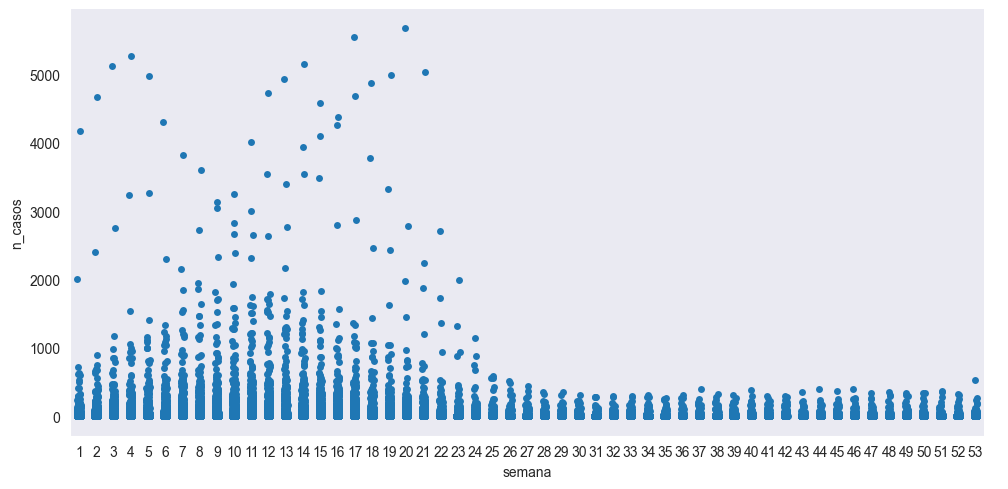

In [35]:
sns.catplot(data = serie, x= 'semana', y = 'n_casos',  height=5, aspect=2)

In [ ]:
correlation = df.corr(numeric_only=True)
correlation.to_excel('correlation_matrix.xlsx')

<Axes: >

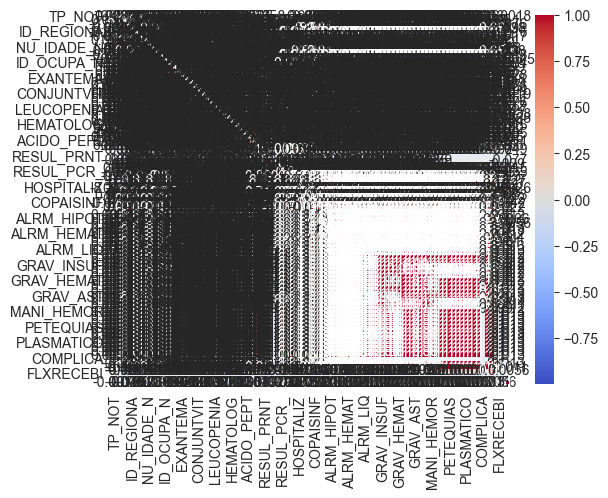

In [42]:
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.0000000001)

Ótimas perguntas. Vamos às variáveis alvo ideais para cada uma:

## Análise 1: Quantidade de infectados no próximo mês

**Problema:** Previsão de série temporal (regressão)

**Variável alvo:** Contagem agregada de casos por município + semana/mês

Não é uma coluna do dataset — você precisa **agregar** os dados:
```python
# Agregar por município e semana epidemiológica
serie = df.groupby(['ID_MUNICIP', 'SEM_PRI']).size().reset_index(name='n_casos')
```
`n_casos` será sua variável alvo para prever quantos casos virão no próximo mês.

## Análise 2: Gravidade de cada caso

**Problema:** Classificação binária

**Variável alvo sugerida:** `HOSPITALIZ`

| Opção | Vantagem | Desvantagem |
|-------|----------|-------------|
| **`HOSPITALIZ`** (1=Sim, 2=Não) | Mais direta, poucos nulos | Só 1-2% são "Sim" |
| **`EVOLUCAO`** (1=cura, 2=óbito) | Mede desfecho real | Muito desbalanceada (~0.1% óbito) |
| **`CLASSI_FIN`** (10=dengue, 11=chik) | Mais平衡 | Não mede gravidade de fato |

**Recomendação: `HOSPITALIZ`** como proxy de gravidade. Se quiser algo mais refinado, crie um **score de gravidade** composto pelos sinais de alarme + gravidade (ex: soma de `ALRM_*` + `GRAV_*`).

## Análise 3: Priorização de municípios

**Problema:** Combinação das duas anteriores → ranking

**Variável alvo:** Score composto por município

```python
prioridade = (
    previsao_casos * peso_1 +
    proporcao_graves * peso_2
)
```

Onde:
- `previsao_casos` = output da Análise 1 (casos esperados no próximo mês)
- `proporcao_graves` = output da Análise 2 (ex: % de hospitalizações no município)

**Não há uma coluna pronta** — você constrói o score combinando os resultados das duas análises anteriores.

---

**Resumo das variáveis alvo:**

| Análise | Tipo | Variável Alvo |
|---------|------|---------------|
| 1. Infectados próximo mês | Regressão (série temporal) | `n_casos` (agregado por município+semana) |
| 2. Gravidade de cada caso | Classificação binária | `HOSPITALIZ` |
| 3. Priorizar municípios | Ranking (score composto) | Score = f(previsão_casos, %_graves) |

In [36]:
# Quero saber a quantidade de infectados no proximo mes 1
# Quero saber a gravidade de cada caso 2
# Quero saber de acordo com a previsão 1 e com q previsao 2 quanto devo priorizar aquele municipio


## Analise 1

<p>Quero saber a quantidade de infectados no proximo mes

Se eu preciso saber a quantidade de pessoas penso logo em um modelo supervisionado.

Posso em modelos de series temporais como o ARIMA e o PROMPHET

<p>- Dados disponiveis : conjunto de dados do nootebook
    <p>-Preciso antes fazer o agrupamento dos dados por mes
    <p>-Preciso fazer a limpeza dos dados para remover nulos e melhorar a qualidade dos dados
    <p>-Preciso entender os hiperparametros dessa lib primeiro

# Aplicação do ARIMA

In [37]:
from pmdarima.arima import auto_arima

In [38]:
model_arima = auto_arima(serie, start_p=1, start_q=1,max_p = 6, max_q = 6,  m=12, start_P = 0,d=1,D=1,seasonal=True, trace=True, error_action='ignore', suppress_warnings=True, stepwise=True)

ValueError: y should be a 1d array, got an array of shape (112065, 3) instead.